## Imports

In [13]:
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt

## load data

In [14]:
data_path = Path("../data/generated/pressure_drop_data.csv")

df = pd.read_csv(data_path)
df.head()

,density_kg_m3,viscosity_pa_s,pipe_diameter_m,velocity_m_s,beta,reynolds_number,loss_coefficient,pressure_drop_clean_pa,pressure_drop_noisy_pa,noise_pa
0,1027.395605,0.000831,0.149731,1.868264,0.670386,345895.324138,3.951072,7084.335800,6722.652668,-361.683131
1,993.887844,0.001098,0.148023,0.693475,0.797903,92937.413920,1.467170,350.630096,340.040491,-10.589605
2,1035.859792,0.001160,0.056485,1.649929,0.320489,83214.368801,93.787127,132234.426120,135764.656464,3530.230345
3,1019.736803,0.000800,0.026598,4.072190,0.422460,138065.332961,30.394877,256989.072274,256682.792313,-306.279962
4,959.417735,0.000726,0.074684,2.568702,0.598870,253409.854420,6.774432,21442.628227,20931.004068,-511.624159


##basic overview

In [15]:
df.shape

(5000, 10)

In [16]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
density_kg_m3,5000.0,999.561236,28.852706,950.051874,974.440813,999.198290,1024.866121,1.049977e+03
viscosity_pa_s,5000.0,0.000999,0.000173,0.000700,0.000849,0.001003,0.001145,1.299986e-03
pipe_diameter_m,5000.0,0.110291,0.051547,0.020002,0.064975,0.110930,0.154596,1.999905e-01
velocity_m_s,5000.0,2.620431,1.399274,0.200092,1.400504,2.647027,3.829358,4.997883e+00
beta,5000.0,0.550107,0.144727,0.300086,0.425115,0.549748,0.678672,7.999912e-01
reynolds_number,5000.0,298500.794161,236139.244690,5356.275992,111271.875626,234346.648570,435438.604807,1.382010e+06
loss_coefficient,5000.0,22.568343,27.924150,1.441513,3.713672,9.948273,29.617966,1.223160e+02
pressure_drop_clean_pa,5000.0,100914.309078,185985.556909,32.239287,7691.467524,27107.227619,100830.322381,1.488988e+06
pressure_drop_noisy_pa,5000.0,101109.388791,186914.011598,35.098521,7756.733572,26919.538031,99978.809682,1.558310e+06
noise_pa,5000.0,195.079713,10820.515816,-99678.801480,-702.392186,3.720998,836.042987,1.845105e+05


In [17]:
df.isna().sum()

density_kg_m3             0
viscosity_pa_s            0
pipe_diameter_m           0
velocity_m_s              0
beta                      0
reynolds_number           0
loss_coefficient          0
pressure_drop_clean_pa    0
pressure_drop_noisy_pa    0
noise_pa                  0
dtype: int64

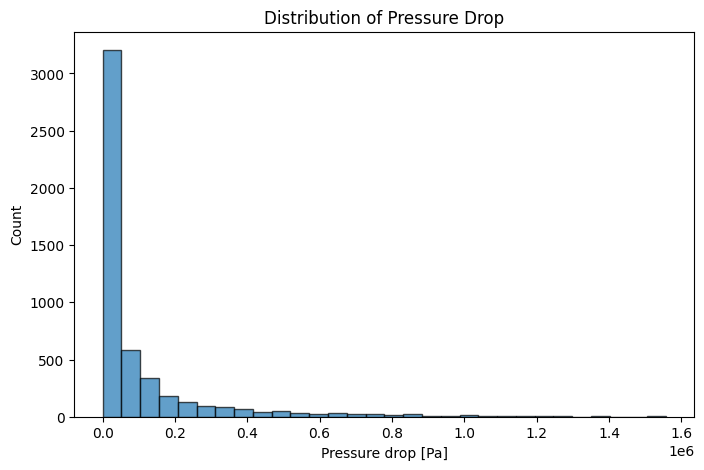

In [19]:
plt.figure(figsize=(8, 5))
plt.hist(df["pressure_drop_noisy_pa"], bins=30, edgecolor="k", alpha=0.7)
plt.xlabel("Pressure drop [Pa]")
plt.ylabel("Count")
plt.title("Distribution of Pressure Drop")
plt.show()

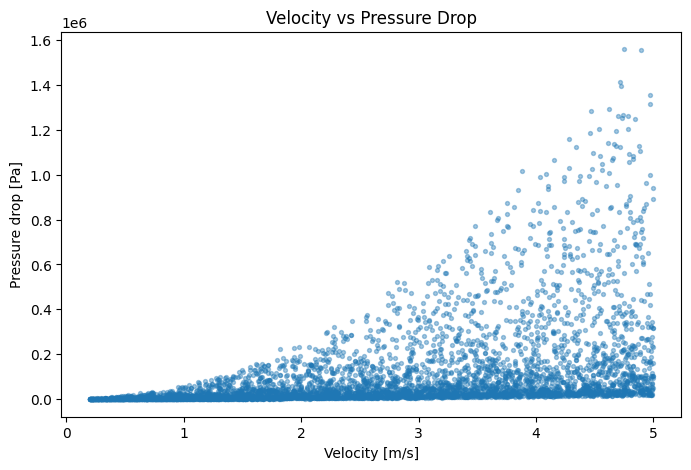

In [21]:
plt.figure(figsize=(8, 5))
plt.scatter(df["velocity_m_s"], df["pressure_drop_noisy_pa"], s=8, alpha=0.4)
plt.xlabel("Velocity [m/s]")
plt.ylabel("Pressure drop [Pa]")
plt.title("Velocity vs Pressure Drop")
plt.show()

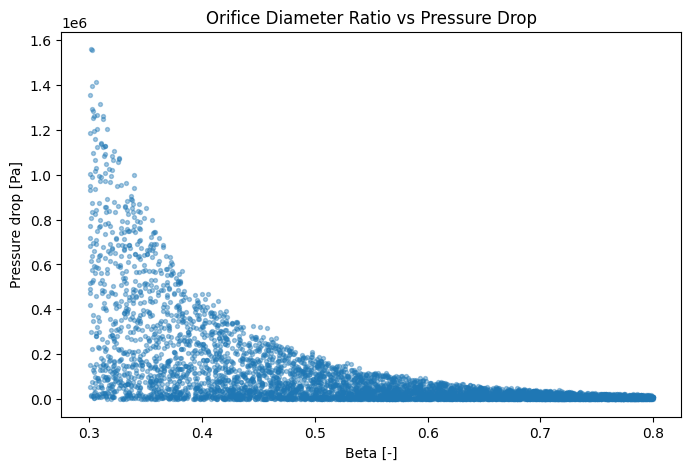

In [22]:
plt.figure(figsize=(8, 5))
plt.scatter(df["beta"], df["pressure_drop_noisy_pa"], s=8, alpha=0.4)
plt.xlabel("Beta [-]")
plt.ylabel("Pressure drop [Pa]")
plt.title("Orifice Diameter Ratio vs Pressure Drop")
plt.show()

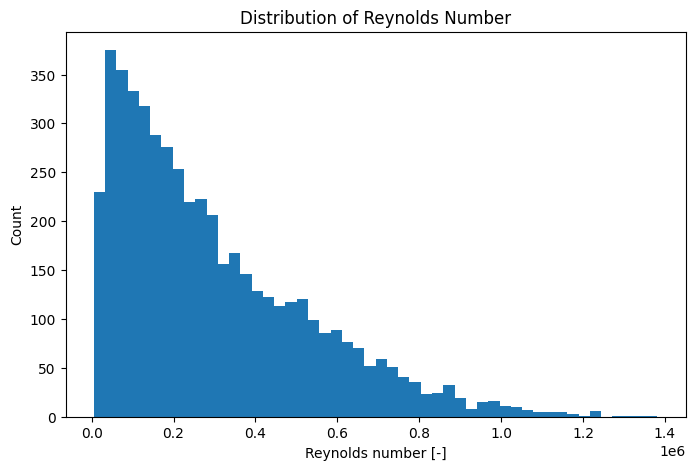

In [ ]:
plt.figure(figsize=(8, 5))
plt.hist(df["reynolds_number"], bins=50)
plt.xlabel("Reynolds number [-]")
plt.ylabel("Count")
plt.title("Distribution of Reynolds Number")
plt.show()

#the graph 

In [ ]:
corr = df.corr(numeric_only=True)["pressure_drop_noisy_pa"].sort_values(ascending=False)
corr

#negative viscosity correlation is expected since higher viscosity means lower velocity and thus lower pressure drop

pressure_drop_noisy_pa    1.000000
pressure_drop_clean_pa    0.998328
loss_coefficient          0.685708
velocity_m_s              0.451257
reynolds_number           0.332583
noise_pa                  0.114537
density_kg_m3             0.022891
pipe_diameter_m           0.018594
viscosity_pa_s           -0.023156
beta                     -0.565467
Name: pressure_drop_noisy_pa, dtype: float64

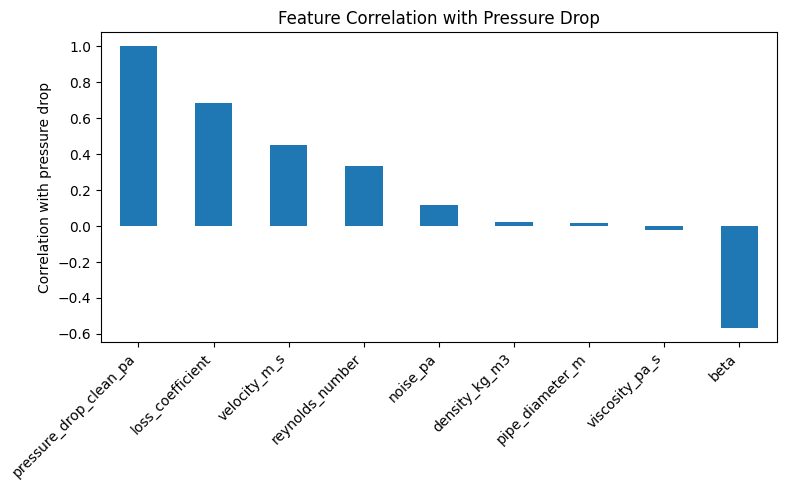

In [ ]:
plt.figure(figsize=(8, 5))
corr.drop("pressure_drop_noisy_pa").plot(kind="bar")
plt.ylabel("Correlation with pressure drop")
plt.title("Feature Correlation with Pressure Drop")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

#negative beta correlation is expected since smaller beta means larger orifice and thus higher velocity and pressure drop

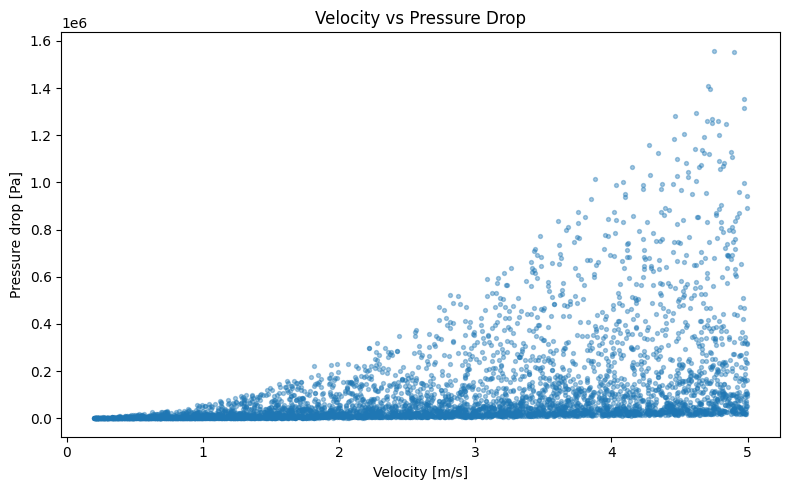

In [27]:
output_dir = Path("../figures/generated")
output_dir.mkdir(parents=True, exist_ok=True)

plt.figure(figsize=(8, 5))
plt.scatter(df["velocity_m_s"], df["pressure_drop_noisy_pa"], s=8, alpha=0.4)
plt.xlabel("Velocity [m/s]")
plt.ylabel("Pressure drop [Pa]")
plt.title("Velocity vs Pressure Drop")
plt.tight_layout()
plt.savefig(output_dir / "velocity_vs_pressure_drop.png", dpi=150)
plt.show()